In [1]:
# ============================================================
# ENSEMBLE EVALUATION — COMBINE TOP MODELS TO BEAT BEST SINGLE MODEL
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"
IMG_SIZE = 128
BATCH_SIZE = 32
CHECKPOINTS_DIR = "checkpoints"

# ---- Load test data ----
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_tf)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
class_names = test_ds.classes
NUM_CLASSES = len(class_names)

# ---- Model builder (covers all your trained architectures) ----
def build_model(name, num_classes):
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

# ---- Candidate models to ensemble (pick your top performers) ----
CANDIDATES = [
    {"name": "efficientnet_b0", "run_tag": "efficientnet_b0_full"},
    {"name": "shufflenet_v2",   "run_tag": "shufflenet_v2_full"},
    {"name": "shufflenet_v2",   "run_tag": "shufflenet_v2_partial"},
    {"name": "mobilenet_v3_small", "run_tag": "mobilenet_v3_small_full"},
]

loaded_models = {}
for c in CANDIDATES:
    ckpt_path = os.path.join(CHECKPOINTS_DIR, c["run_tag"], "best_model.pth")
    if not os.path.exists(ckpt_path):
        print(f"WARNING: missing checkpoint for {c['run_tag']} — skipping")
        continue
    model = build_model(c["name"], NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    loaded_models[c["run_tag"]] = model
    print(f"Loaded: {c['run_tag']}")

# ---- Collect per-model softmax probabilities on the test set (compute once) ----
def get_all_probs(model, loader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.extend(labels.numpy())
    return np.concatenate(all_probs, axis=0), np.array(all_labels)

model_probs = {}
true_labels = None
for tag, model in loaded_models.items():
    probs, labels = get_all_probs(model, test_loader)
    model_probs[tag] = probs
    true_labels = labels
    acc = accuracy_score(labels, probs.argmax(axis=1))
    f1 = f1_score(labels, probs.argmax(axis=1), average="macro")
    print(f"{tag}: standalone acc={acc:.4f} macro-F1={f1:.4f}")

/tmp/ipykernel_50520/2506109921.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))


Loaded: efficientnet_b0_full
Loaded: shufflenet_v2_full
Loaded: shufflenet_v2_partial
Loaded: mobilenet_v3_small_full
efficientnet_b0_full: standalone acc=0.9200 macro-F1=0.9197
shufflenet_v2_full: standalone acc=0.9200 macro-F1=0.9158
shufflenet_v2_partial: standalone acc=0.9050 macro-F1=0.9115
mobilenet_v3_small_full: standalone acc=0.8850 macro-F1=0.8845


In [2]:
# ============================================================
# TRY ALL COMBINATIONS OF 2-4 MODELS, FIND BEST ENSEMBLE
# ============================================================
model_tags = list(model_probs.keys())
ensemble_results = []

for r in range(2, len(model_tags) + 1):
    for combo in combinations(model_tags, r):
        avg_probs = np.mean([model_probs[tag] for tag in combo], axis=0)
        preds = avg_probs.argmax(axis=1)
        acc = accuracy_score(true_labels, preds)
        f1 = f1_score(true_labels, preds, average="macro")
        ensemble_results.append({
            "combo": " + ".join(combo),
            "n_models": r,
            "test_accuracy": round(acc, 4),
            "test_macro_f1": round(f1, 4),
        })

ensemble_df = pd.DataFrame(ensemble_results).sort_values("test_macro_f1", ascending=False)
print(ensemble_df.to_string(index=False))

                                                                                      combo  n_models  test_accuracy  test_macro_f1
efficientnet_b0_full + shufflenet_v2_full + shufflenet_v2_partial + mobilenet_v3_small_full         4          0.935         0.9378
                     efficientnet_b0_full + shufflenet_v2_partial + mobilenet_v3_small_full         3          0.930         0.9360
                                            shufflenet_v2_partial + mobilenet_v3_small_full         2          0.930         0.9356
                       shufflenet_v2_full + shufflenet_v2_partial + mobilenet_v3_small_full         3          0.935         0.9349
                                               efficientnet_b0_full + shufflenet_v2_partial         2          0.935         0.9334
                                             efficientnet_b0_full + mobilenet_v3_small_full         2          0.925         0.9329
                          efficientnet_b0_full + shufflenet_v2_full + shuffl

In [1]:
# ============================================================
# GENERATE test_predictions_log.csv FOR THE ENSEMBLE
# ============================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"
IMG_SIZE = 128
BATCH_SIZE = 32
CHECKPOINTS_DIR = "checkpoints"

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_tf)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
class_names = test_ds.classes
NUM_CLASSES = len(class_names)
test_samples = test_ds.samples  # (filepath, true_label_idx), in the same order as test_loader (shuffle=False)

def build_model(name, num_classes):
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

# same 4 components as your best ensemble
CANDIDATES = [
    {"name": "efficientnet_b0", "run_tag": "efficientnet_b0_full"},
    {"name": "shufflenet_v2",   "run_tag": "shufflenet_v2_full"},
    {"name": "shufflenet_v2",   "run_tag": "shufflenet_v2_partial"},
    {"name": "mobilenet_v3_small", "run_tag": "mobilenet_v3_small_full"},
]

loaded_models = []
for c in CANDIDATES:
    ckpt_path = os.path.join(CHECKPOINTS_DIR, c["run_tag"], "best_model.pth")
    model = build_model(c["name"], NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    loaded_models.append(model)
    print(f"Loaded: {c['run_tag']}")

# ---- run ensemble inference, image-by-image tracking ----
prediction_log = []
idx = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)

        # average softmax probabilities across all 4 models
        probs_sum = None
        for model in loaded_models:
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            probs_sum = probs if probs_sum is None else probs_sum + probs
        avg_probs = probs_sum / len(loaded_models)

        preds = avg_probs.argmax(dim=1)
        confidences = avg_probs.max(dim=1).values

        for i in range(imgs.size(0)):
            filepath, true_idx = test_samples[idx]
            pred_idx = preds[i].item()
            prediction_log.append({
                "image_path": filepath,
                "true_class": class_names[true_idx],
                "predicted_class": class_names[pred_idx],
                "confidence": round(confidences[i].item(), 4),
                "correct": true_idx == pred_idx,
            })
            idx += 1

pred_log_df = pd.DataFrame(prediction_log)
SAVE_DIR = os.path.join(CHECKPOINTS_DIR, "best_ensemble")
os.makedirs(SAVE_DIR, exist_ok=True)
pred_log_df.to_csv(os.path.join(SAVE_DIR, "test_predictions_log.csv"), index=False)

print(f"\nSaved: {os.path.join(SAVE_DIR, 'test_predictions_log.csv')}")
print(f"Total: {len(pred_log_df)} | Correct: {pred_log_df['correct'].sum()} | Incorrect: {(~pred_log_df['correct']).sum()}")

/tmp/ipykernel_12487/94682775.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))


Loaded: efficientnet_b0_full
Loaded: shufflenet_v2_full
Loaded: shufflenet_v2_partial
Loaded: mobilenet_v3_small_full

Saved: checkpoints/best_ensemble/test_predictions_log.csv
Total: 200 | Correct: 187 | Incorrect: 13


Best ensemble: efficientnet_b0_full + shufflenet_v2_full + shufflenet_v2_partial + mobilenet_v3_small_full
Test accuracy: 0.935
Test macro-F1: 0.9378
{
  "model": "ensemble_efficientnet_b0_full_shufflenet_v2_full_shufflenet_v2_partial_mobilenet_v3_small_full",
  "train_mode": "weighted_average_ensemble",
  "test_accuracy": 0.935,
  "test_macro_f1": 0.93779755814397,
  "test_precision": 0.9428503787878788,
  "test_recall": 0.939330808080808,
  "total_params": 8102308,
  "trainable_params": 8102308,
  "model_size_mb": 30.908,
  "inference_ms_per_image": null
}


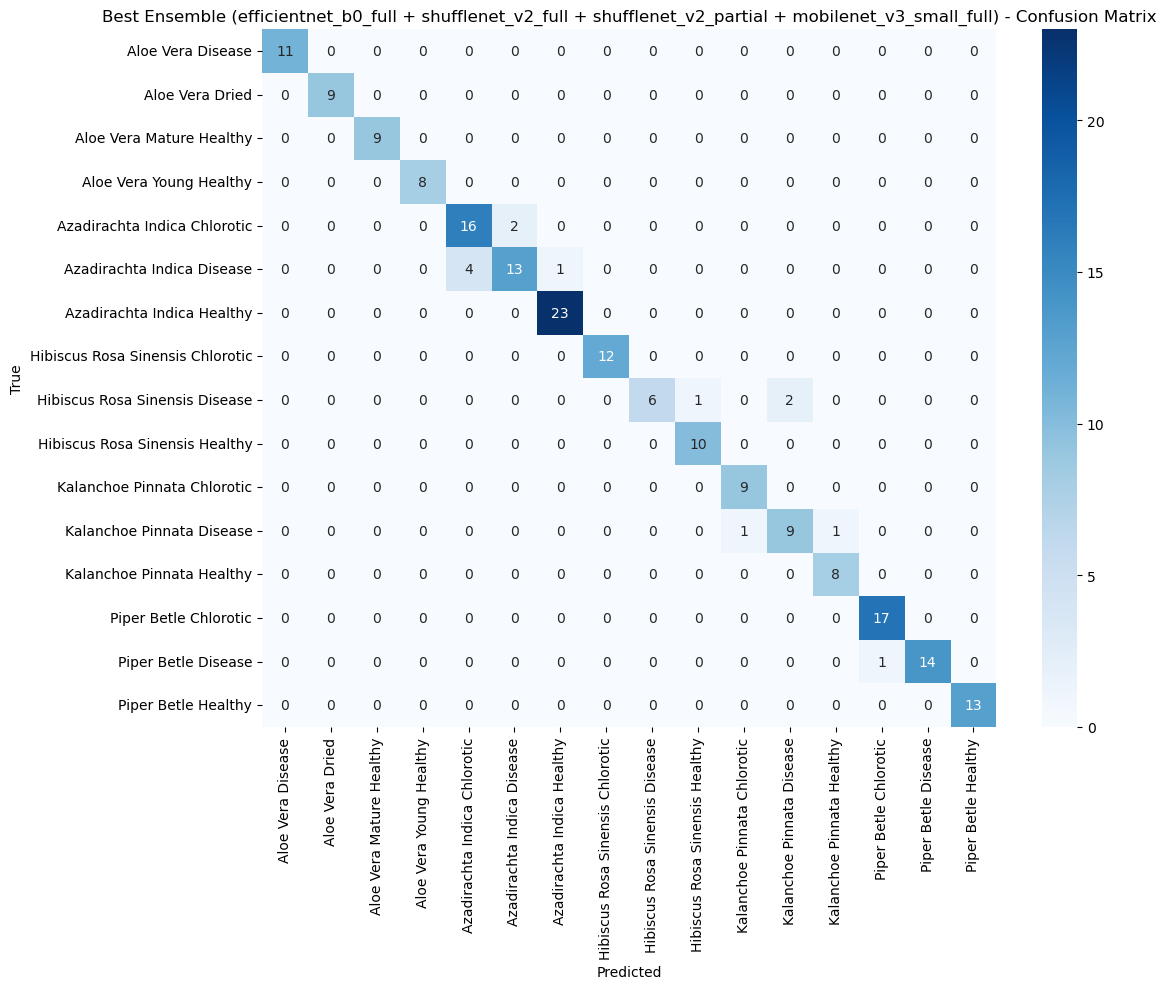

In [ ]:
# ============================================================
# EVALUATE BEST ENSEMBLE IN FULL DETAIL
# ============================================================
best_combo_str = ensemble_df.iloc[0]["combo"]
best_combo = best_combo_str.split(" + ")
print(f"Best ensemble: {best_combo_str}")
print(f"Test accuracy: {ensemble_df.iloc[0]['test_accuracy']}")
print(f"Test macro-F1: {ensemble_df.iloc[0]['test_macro_f1']}")

avg_probs = np.mean([model_probs[tag] for tag in best_combo], axis=0)
preds = avg_probs.argmax(axis=1)

precision = precision_score(true_labels, preds, average="macro", zero_division=0)
recall = recall_score(true_labels, preds, average="macro", zero_division=0)

# combined size/param cost of the ensemble
total_params = sum(sum(p.numel() for p in loaded_models[tag].parameters()) for tag in best_combo)
total_size_mb = total_params * 4 / (1024 ** 2)


ensemble_results_final = {
    "model": "ensemble_" + "_".join(best_combo),
    "train_mode": "weighted_average_ensemble",
    "test_accuracy": accuracy_score(true_labels, preds),
    "test_macro_f1": f1_score(true_labels, preds, average="macro"),
    "test_precision": precision,
    "test_recall": recall,
    "total_params": total_params,
    "trainable_params": total_params,
    "model_size_mb": round(total_size_mb, 3),
    "inference_ms_per_image": None,  # sum of individual model times, measure separately if needed
}

SAVE_DIR = os.path.join(CHECKPOINTS_DIR, "best_ensemble")
os.makedirs(SAVE_DIR, exist_ok=True)
import json
with open(os.path.join(SAVE_DIR, "results.json"), "w") as f:
    json.dump(ensemble_results_final, f, indent=2)

print(json.dumps(ensemble_results_final, indent=2))

# confusion matrix for best ensemble
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Best Ensemble ({best_combo_str}) - Confusion Matrix")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300)
plt.show()